# Week 6 Linear and Logistic Regression
> by Lei Ding, Updated Mar. 2025

In [1]:
# 准备
#install.packages('visdat')
#install.packages('corrplot')
#install.packages('caret')
#install.packages('dplyr')
#install.packages('caTools')

## 1. 线性回归

### 1.1 run数据集上的简单线性回归

In [2]:
# 1. 数据准备
firstrun <- rnorm(99, 30, 10)
secondrun <- firstrun + rnorm(99, 5, 2)
finalrun <- secondrun + rnorm(99, 7, 3)
run <- data.frame(firstrun, secondrun, finalrun)
run

firstrun,secondrun,finalrun
<dbl>,<dbl>,<dbl>
32.77778,39.34824,46.55787
22.90195,29.80185,38.58720
39.98622,47.94902,54.81277
43.52637,49.75884,59.25160
54.27975,55.78888,62.32233
16.14909,21.12131,28.23198
41.43533,45.04999,60.69819
46.08855,49.29577,53.83785
35.15029,43.21093,42.82291


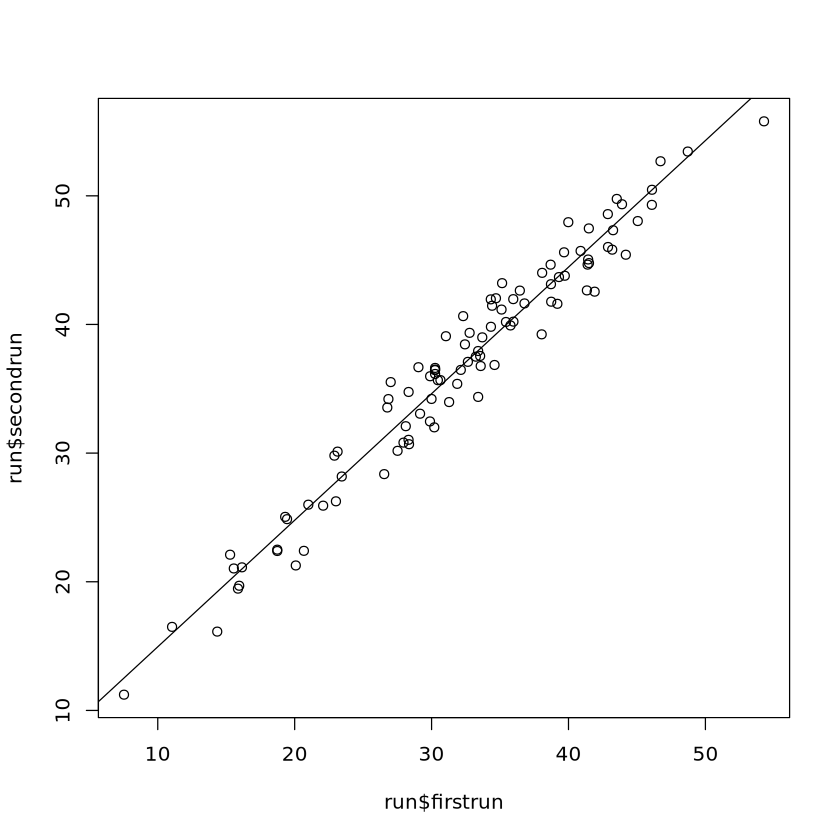

In [3]:
# 2. 简单线性回归模型
plot(run$firstrun, run$secondrun)  # 散点图
reg1 <- lm(run$secondrun ~ run$firstrun)  # formula
abline(reg1)

In [4]:
# 3. 计算相关性系数
cor(run$firstrun, run$secondrun)

[1] 0.9785894

In [5]:
# 4. 相关性检验
cor.test(run$firstrun, run$secondrun)  # 默认method='pearson'


	Pearson's product-moment correlation

data:  run$firstrun and run$secondrun
t = 46.827, df = 97, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9682241 0.9855983
sample estimates:
      cor 
0.9785894 


In [6]:
# 5. 回归模型摘要
summary(reg1)

# Residuals: 残差的整体分布情况，残差越小，拟合越好
# Coefficients: 系数，显著性水平越高说明对应的变量与因变量的关系更有意义（更可靠）
# Residual standard error: 标准残差误，越小越好，残差自由度=样本数-自变量数-1
# Multiple R-squared / Adjusted: 多重R方，位于[0,1]之间，越大越好
# F-statistics: F统计量（具有两个自由度），指F检验的p值


Call:
lm(formula = run$secondrun ~ run$firstrun)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7886 -1.2864 -0.0304  1.4763  3.8367 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   5.10738    0.70278   7.267 9.33e-11 ***
run$firstrun  0.98378    0.02101  46.827  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.896 on 97 degrees of freedom
Multiple R-squared:  0.9576,	Adjusted R-squared:  0.9572 
F-statistic:  2193 on 1 and 97 DF,  p-value: < 2.2e-16


### 1.2 run数据集上的多元线性回归

In [7]:
# 6. 多元线性回归模型
lma <- lm(finalrun ~ firstrun + secondrun, data=run)
summary(lma)


Call:
lm(formula = finalrun ~ firstrun + secondrun, data = run)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.0939  -1.6661  -0.1434   1.5246   8.6201 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.2227     1.3665   4.554 1.55e-05 ***
firstrun     -0.1251     0.1597  -0.783    0.435    
secondrun     1.1329     0.1589   7.132 1.86e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.967 on 96 degrees of freedom
Multiple R-squared:  0.9088,	Adjusted R-squared:  0.9069 
F-statistic: 478.5 on 2 and 96 DF,  p-value: < 2.2e-16


In [8]:
# 7. 使用回归进行预测
newdata <- data.frame(firstrun=22, secondrun=25)
predict(lma, newdata)

1 
31.79395

In [ ]:
# 8. 使用80%的样本作为训练集建立新的模型
run2 <- run[order(runif(99)),] # r-unif生成99个[0,1)随机浮点数，自小到大排序，返回其下标，相当于随机下标
lma <- lm(finalrun ~ firstrun + secondrun, data=run2[c(1:80),])  # 80%训练
testing <- run2[c(81:99),]  # 20%测试
predictions <- predict(lma, testing)
testing$predictions <- predictions
testing

,firstrun,secondrun,finalrun,predictions
,<dbl>,<dbl>,<dbl>,<dbl>
29,33.232165,37.49569,43.30820,44.45867
26,35.763176,39.92180,46.77907,46.91694
53,28.318100,31.03221,40.52899,37.73786
5,54.279753,55.78888,62.32233,62.81012
83,30.256969,36.15314,41.95007,43.24608
73,38.694500,44.64836,54.72289,51.89382
13,36.785795,41.63550,50.63748,48.72517
2,22.901948,29.80185,38.58720,36.87902
76,43.907691,49.34260,54.47936,56.62064


[1] -0.5408148

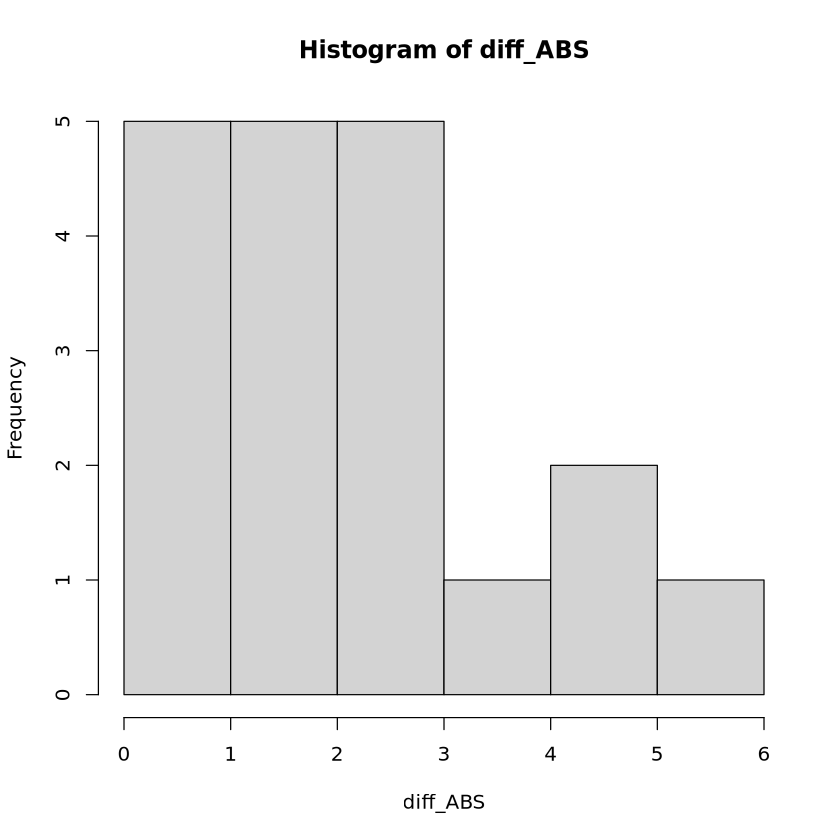

In [10]:
# 9. 新模型预测性能
diff <- predictions - testing$finalrun  # 计算残差
mean(diff)
diff_ABS <- abs(diff)
hist(diff_ABS)

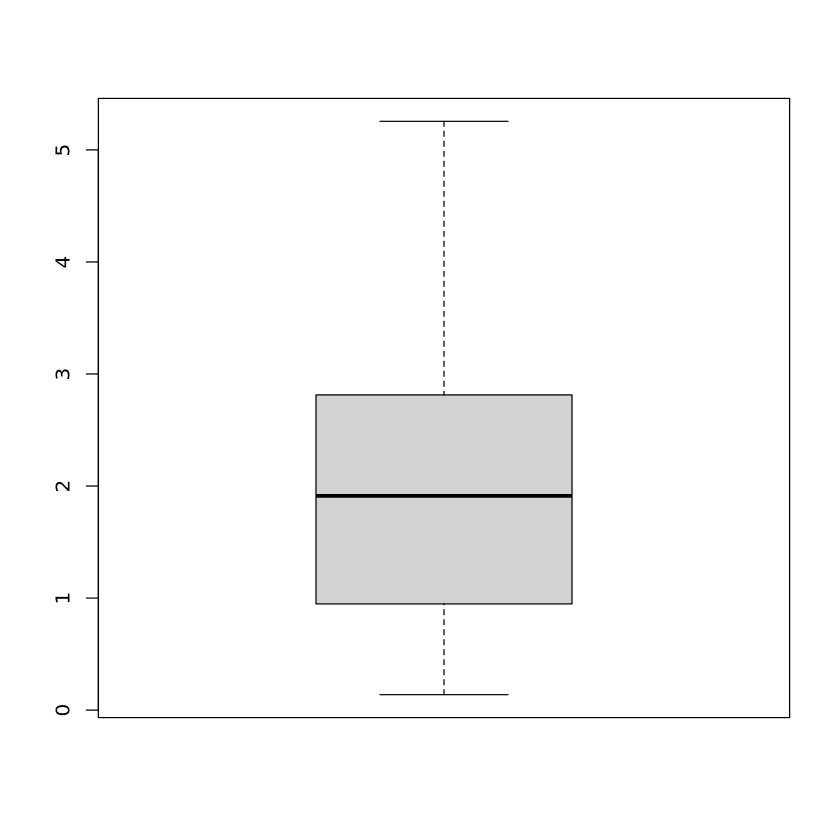

In [11]:
boxplot(diff_ABS)

In [12]:
length(diff_ABS[diff_ABS <= 2])  # 残差小于2的样本数量

[1] 10

### 1.3 红酒质量数据集案例

In [13]:
# 10. 准备数据
df_red <- read.csv("winequality-red.csv", sep=";")
head(df_red)

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
2,7.8,0.88,0.00,2.6,0.098,25,67,0.9968,3.20,0.68,9.8,5
3,7.8,0.76,0.04,2.3,0.092,15,54,0.9970,3.26,0.65,9.8,5
4,11.2,0.28,0.56,1.9,0.075,17,60,0.9980,3.16,0.58,9.8,6
5,7.4,0.70,0.00,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5
6,7.4,0.66,0.00,1.8,0.075,13,40,0.9978,3.51,0.56,9.4,5


[1] 0

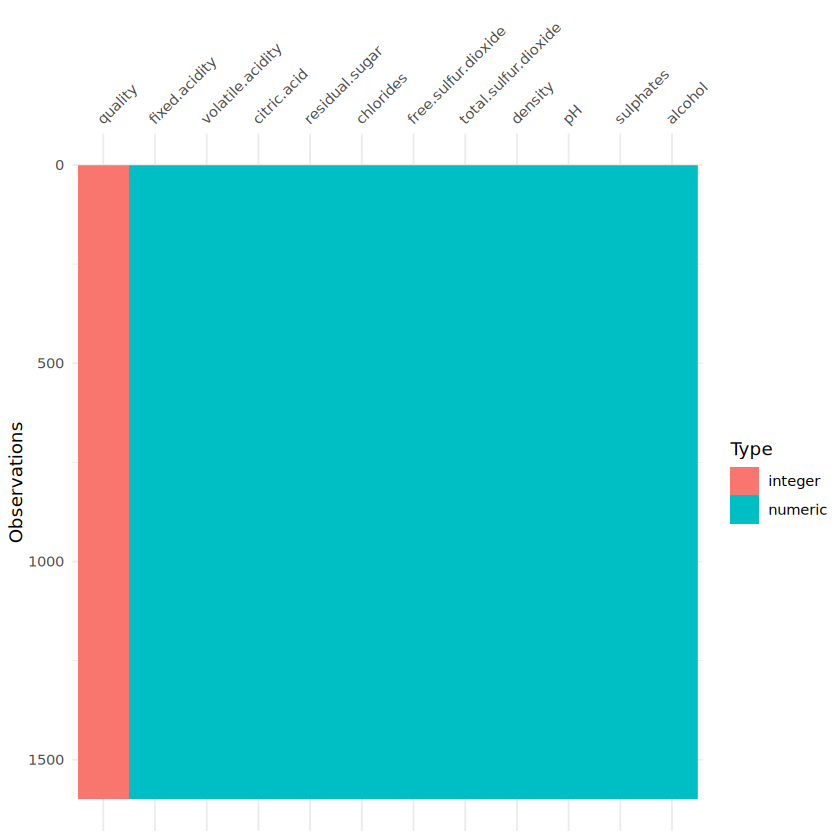

In [14]:
# 11. 缺失值处理
sum(is.na(df_red))
library('visdat')
vis_dat(df_red)  # 无缺失值

corrplot 0.95 loaded



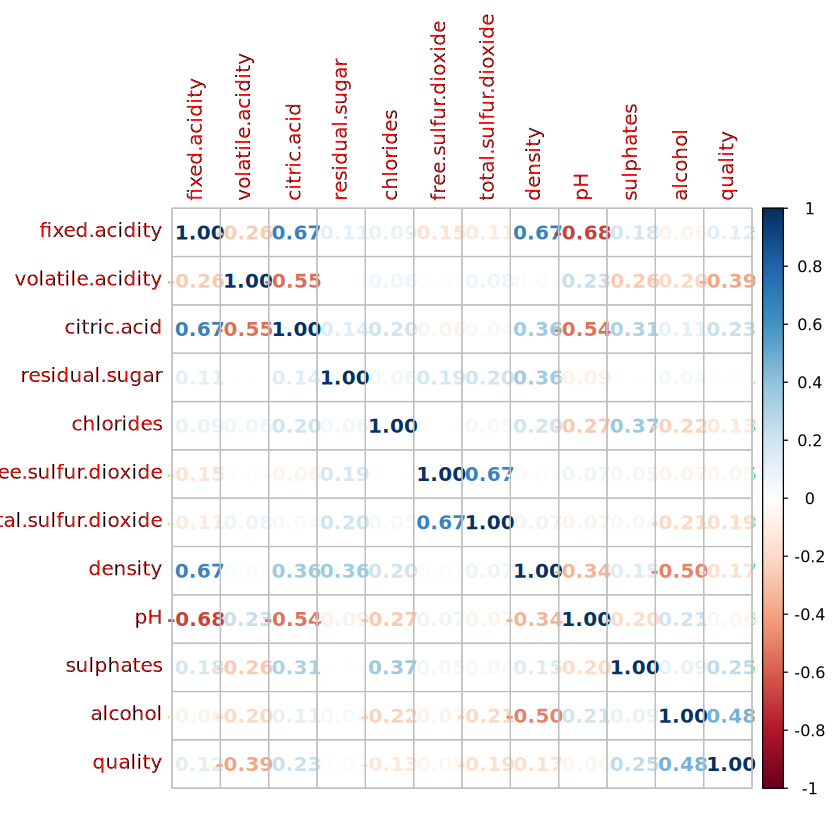

In [15]:
# 12. 相关性分析
library('corrplot')
M <- cor(df_red)
corrplot(M, method='number')

In [16]:
# 13. 随机选择80%样本作为训练集，20%作为测试集
set.seed(1)
sampleSize <- round(nrow(df_red) * 0.8)
idx <- sample(seq_len(sampleSize), size=sampleSize)
train_red <- df_red[idx, ]
test_red <- df_red[-idx, ]

In [17]:
# 14. 使用所有特征建立对红酒质量的回归模型
model_red1 <- lm(quality ~ fixed.acidity + volatile.acidity + 
                 citric.acid + chlorides + free.sulfur.dioxide + 
                 total.sulfur.dioxide + density + pH + 
                 sulphates + alcohol, data=train_red)
summary(model_red1)

# R-square: 36.95%


Call:
lm(formula = quality ~ fixed.acidity + volatile.acidity + citric.acid + 
    chlorides + free.sulfur.dioxide + total.sulfur.dioxide + 
    density + pH + sulphates + alcohol, data = train_red)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.67536 -0.38553 -0.06879  0.45454  1.97578 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           1.510e+01  1.912e+01   0.790 0.429935    
fixed.acidity         1.547e-02  2.696e-02   0.574 0.566286    
volatile.acidity     -1.057e+00  1.358e-01  -7.780 1.49e-14 ***
citric.acid          -1.774e-01  1.657e-01  -1.070 0.284621    
chlorides            -1.779e+00  4.627e-01  -3.845 0.000126 ***
free.sulfur.dioxide   3.392e-03  2.480e-03   1.368 0.171691    
total.sulfur.dioxide -3.645e-03  8.201e-04  -4.444 9.58e-06 ***
density              -1.102e+01  1.954e+01  -0.564 0.572664    
pH                   -3.835e-01  2.010e-01  -1.908 0.056598 .  
sulphates             7.945e-01  1.217e-0

In [18]:
# 15. 使用一个特征建立回归模型
model_red2 <- lm(quality ~ alcohol, data=train_red)
summary(model_red2)

# R-square: 0.2489


Call:
lm(formula = quality ~ alcohol, data = train_red)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.8861 -0.4048 -0.1827  0.5582  2.5581 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.81376    0.18792   9.652   <2e-16 ***
alcohol      0.37021    0.01797  20.601   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7041 on 1277 degrees of freedom
Multiple R-squared:  0.2494,	Adjusted R-squared:  0.2489 
F-statistic: 424.4 on 1 and 1277 DF,  p-value: < 2.2e-16


In [19]:
# 16. 使用相关性最大的5个特征建立回归模型
model_red3 <- lm(quality ~ alcohol + volatile.acidity + 
                 sulphates + citric.acid + density, data=train_red)
summary(model_red3)

# R-square: 0.3397


Call:
lm(formula = quality ~ alcohol + volatile.acidity + sulphates + 
    citric.acid + density, data = train_red)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.7055 -0.4068 -0.0748  0.4949  2.2302 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)      -10.20026   13.12402  -0.777    0.437    
alcohol            0.33403    0.02076  16.089  < 2e-16 ***
volatile.acidity  -1.26276    0.13187  -9.576  < 2e-16 ***
sulphates          0.57332    0.11255   5.094 4.03e-07 ***
citric.acid       -0.16117    0.13303  -1.212    0.226    
density           12.75053   13.08709   0.974    0.330    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6601 on 1273 degrees of freedom
Multiple R-squared:  0.3423,	Adjusted R-squared:  0.3397 
F-statistic: 132.5 on 5 and 1273 DF,  p-value: < 2.2e-16


## 2. 逻辑回归

### 2.1 run数据集上的逻辑回归

In [20]:
# 17. 数据准备
firstrun <- rnorm(99, 30, 10)
secondrun <- firstrun + rnorm(99, 5, 2)
finalrun <- secondrun + rnorm(99, 7, 3)
run <- data.frame(firstrun, secondrun, finalrun)
run$superrun = ifelse(run$finalrun >= 45, 1, 0)  # 新增列，取0、1二值
head(run)

,firstrun,secondrun,finalrun,superrun
,<dbl>,<dbl>,<dbl>,<dbl>
1,44.98273,50.15540,61.24548,1
2,33.71839,40.75341,42.00786,0
3,32.61106,35.67122,36.89972,0
4,29.75456,36.88727,47.29442,1
5,20.82311,27.33413,38.05780,0
6,24.08116,27.67465,31.20214,0


In [21]:
# 18. 随机划分训练集与测试集
sampleSize <- round(nrow(run) * 0.8)
idx <- sample(seq_len(sampleSize), size=sampleSize)
train_run <- run[idx, ]
test_run <- run[-idx, ]

In [22]:
# 19. 逻辑回归模型
logitModel <- glm(superrun ~ firstrun + secondrun, data=train_run, 
                  family=binomial(link='logit'))  # 连接函数，logit函数用于二分类问题（默认）
summary(logitModel)

# Deviance Residuals: 偏差残差（基于对数似然比的残差），用于glm
# Null deviance: 零偏差，模型没有任何自变量时拟合的偏差
# Residual deviance: 残差偏差，包含自变量的偏差，若小于Null deviance，则说明拟合有意义
# AIC: 赤池信息，越小越好

# 结果显示firstrun和secondrun贡献不大


Call:
glm(formula = superrun ~ firstrun + secondrun, family = binomial(link = "logit"), 
    data = train_run)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -21.44097    6.09414  -3.518 0.000434 ***
firstrun     -0.04125    0.18284  -0.226 0.821494    
secondrun     0.59102    0.24768   2.386 0.017021 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 101.468  on 78  degrees of freedom
Residual deviance:  31.368  on 76  degrees of freedom
AIC: 37.368

Number of Fisher Scoring iterations: 8


In [23]:
# 20. 预测结果
probabilities <- predict(logitModel, test_run)
probabilities
predicted <- as.numeric(probabilities > 0.5)
predicted

80           81           82           83           84           85 
  3.95958886  -7.61473571  -7.45478050  -2.13659616  -6.11401188  -5.32374957 
          86           87           88           89           90           91 
 -9.98237388  -7.34647203   4.75862620   0.05211646  -4.68441030  10.88494208 
          92           93           94           95           96           97 
  4.89405210  -7.16561704  -2.34478329 -20.46132691   3.45586434   1.48498179 
          98           99 
 -3.85975198  -4.27061338

[1] 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0

In [24]:
# 21. 真实值
predicted <- as.factor(predicted)
test_run$superrun <- as.factor(test_run$superrun)
test_run$superrun

[1] 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0
Levels: 0 1

In [25]:
# 22. 计算混淆矩阵
library(caret)
confusionMatrix(predicted, test_run$superrun)

# NIR: 不平衡类别中多数类别样本量的比例
# Kappa: 越接近1越好，0为随机猜测，<0很差
# Sensitivity: 灵敏度，召回率
# Specificity: 特异度
# Pos Pred Value: 正例预测率，准确率
# Neg Pred Value: 负例预测率

Loading required package: ggplot2

Loading required package: lattice



Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 14  0
         1  0  6
                                     
               Accuracy : 1          
                 95% CI : (0.8316, 1)
    No Information Rate : 0.7        
    P-Value [Acc > NIR] : 0.0007979  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         
                                     
            Sensitivity : 1.0        
            Specificity : 1.0        
         Pos Pred Value : 1.0        
         Neg Pred Value : 1.0        
             Prevalence : 0.7        
         Detection Rate : 0.7        
   Detection Prevalence : 0.7        
      Balanced Accuracy : 1.0        
                                     
       'Positive' Class : 0          
                                     

In [26]:
# 23. 回归系数与优势比
coef(logitModel)
exp(coef(logitModel))

(Intercept)     firstrun    secondrun 
-21.44096915  -0.04125209   0.59102154

(Intercept)     firstrun    secondrun 
4.878715e-10 9.595872e-01 1.805832e+00

In [27]:
# 24. 优势比的置信区间
exp(cbind(OR=coef(logitModel), confint(logitModel)))

Waiting for profiling to be done...

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


,OR,2.5 %,97.5 %
(Intercept),4.878715e-10,1.169365e-16,5.624757e-06
firstrun,9.595872e-01,6.620960e-01,1.381464e+00
secondrun,1.805832e+00,1.174020e+00,3.173891e+00


### 2.2 Titanic数据集逻辑回归

In [28]:
# 25. 数据准备
df <- read.csv('train.csv', na.strings='')
head(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NA,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NA,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NA,S
6,6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,NA,Q


[1] 687

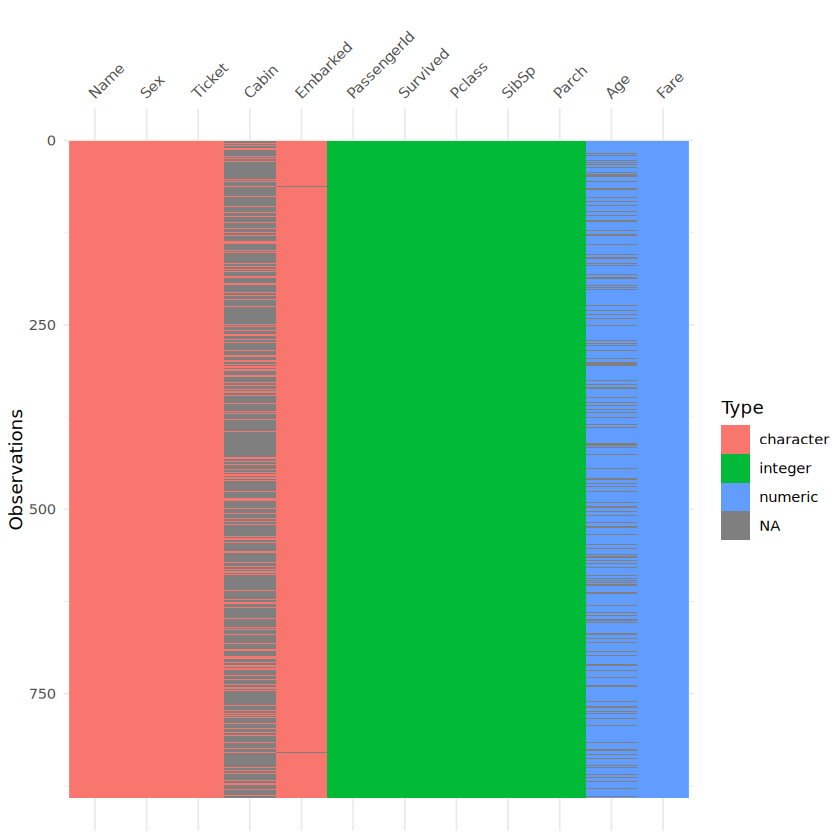

In [29]:
# 26. 缺失值检测
sum(is.na(df$Cabin))
library('visdat')
vis_dat(df)

Warning message:
“Removed 177 rows containing non-finite outside the scale range (`stat_boxplot()`).”


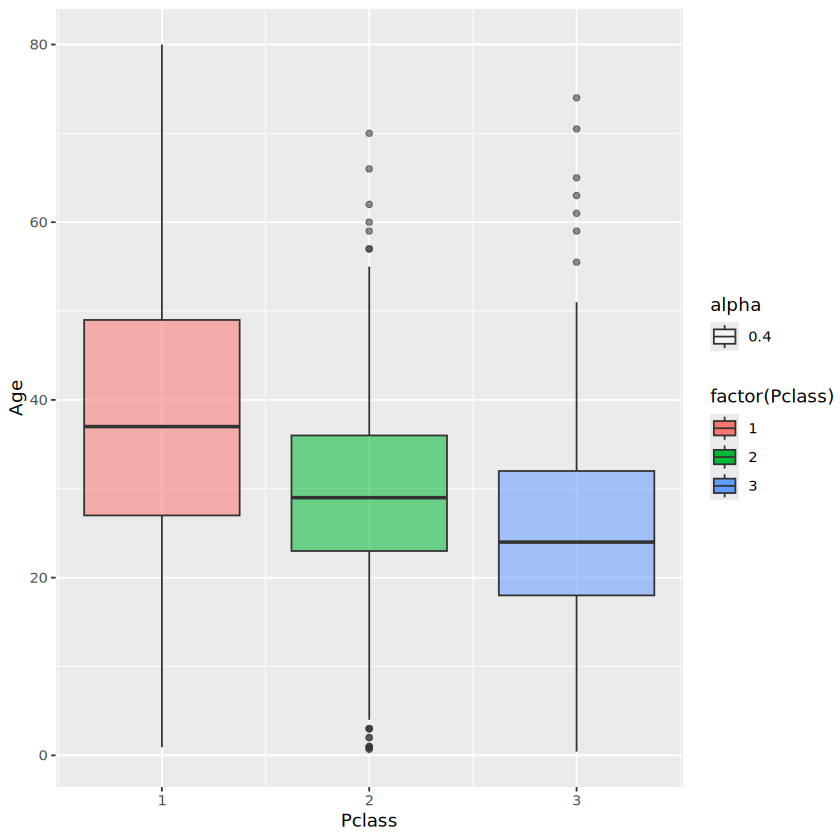

In [30]:
# 27. 年龄缺失值的处理
library(ggplot2)
ggplot(df, aes(Pclass, Age)) + geom_boxplot(aes(group=Pclass, fill=factor(Pclass), alpha=0.4))

In [31]:
sum(is.na(df$Age))

[1] 177

In [32]:
# 按Pclass的分组平均年龄填充
avg_P1 = round(mean(df[df$Pclass==1,]$Age, na.rm=TRUE))
avg_P2 = round(mean(df[df$Pclass==2,]$Age, na.rm=TRUE))
avg_P3 = round(mean(df[df$Pclass==3,]$Age, na.rm=TRUE))
impute_age <- function(age, class) {
    out <- age
    for (i in 1:length(age)) {
        if (is.na(age[i])) {
            if (class[i] == 1) {
                out[i] <- avg_P1
            } else if (class[i] == 2) {
                out[i] <- avg_P2
            } else {
                out[i] <- avg_P3
            }
        } else {
            out[i] <- age[i]
        }
    }
    return(out)
}
fixed.ages <- impute_age(df$Age, df$Pclass)
df$Age <- fixed.ages
sum(is.na(df$Age))
str(df)

[1] 0

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 25 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  NA "C85" NA "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...


'data.frame':	202 obs. of  12 variables:
 $ PassengerId: int  2 4 7 11 12 22 24 28 32 53 ...
 $ Survived   : int  1 1 0 1 1 1 1 0 1 1 ...
 $ Pclass     : int  1 1 1 3 1 2 1 1 1 1 ...
 $ Name       : chr  "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" "McCarthy, Mr. Timothy J" "Sandstrom, Miss. Marguerite Rut" ...
 $ Sex        : chr  "female" "female" "male" "female" ...
 $ Age        : num  38 35 54 4 58 34 28 19 38 49 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 1 1 ...
 $ Parch      : int  0 0 0 1 0 0 0 2 0 0 ...
 $ Ticket     : chr  "PC 17599" "113803" "17463" "PP 9549" ...
 $ Fare       : num  71.3 53.1 51.9 16.7 26.6 ...
 $ Cabin      : chr  "C85" "C123" "E46" "G6" ...
 $ Embarked   : chr  "C" "S" "S" "S" ...
 - attr(*, "na.action")= 'omit' Named int [1:689] 1 3 5 6 8 9 10 13 14 15 ...
  ..- attr(*, "names")= chr [1:689] "1" "3" "5" "6" ...


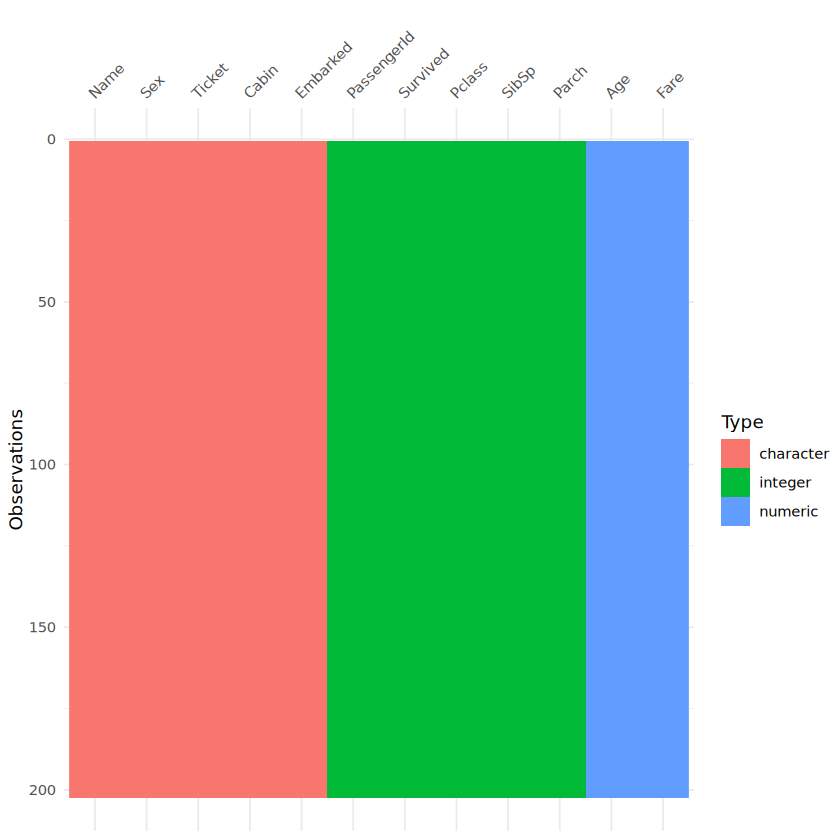

In [33]:
# 28. 删除其他缺失值
df <- na.omit(df)
str(df)
vis_dat(df)

In [34]:
# 29. 转换为因子特征
df$Survived <- factor(df$Survived)
df$Pclass <- factor(df$Pclass)
# df$Parch <- factor(df$Parch)  # 若测试集中出现训练集中未曾出现的因子，则报错
df$SibSp <- factor(df$SibSp)

In [35]:
# 30. 去掉无关的列
library(dplyr)
df <- select(df, -PassengerId, -Name, -Ticket, -Cabin)
str(df)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




'data.frame':	202 obs. of  8 variables:
 $ Survived: Factor w/ 2 levels "0","1": 2 2 1 2 2 2 2 1 2 2 ...
 $ Pclass  : Factor w/ 3 levels "1","2","3": 1 1 1 3 1 2 1 1 1 1 ...
 $ Sex     : chr  "female" "female" "male" "female" ...
 $ Age     : num  38 35 54 4 58 34 28 19 38 49 ...
 $ SibSp   : Factor w/ 4 levels "0","1","2","3": 2 2 1 2 1 1 1 4 2 2 ...
 $ Parch   : int  0 0 0 1 0 0 0 2 0 0 ...
 $ Fare    : num  71.3 53.1 51.9 16.7 26.6 ...
 $ Embarked: chr  "C" "S" "S" "S" ...
 - attr(*, "na.action")= 'omit' Named int [1:689] 1 3 5 6 8 9 10 13 14 15 ...
  ..- attr(*, "names")= chr [1:689] "1" "3" "5" "6" ...


In [36]:
# 31. 逻辑回归模型
log.model <- glm(formula=Survived ~ ., family=binomial(link='logit'), data=df)  # 所有特征
summary(log.model)

# Sexmale与Age是最显著的两个特征


Call:
glm(formula = Survived ~ ., family = binomial(link = "logit"), 
    data = df)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.573127   0.943490   4.847 1.25e-06 ***
Pclass2      0.109315   0.841556   0.130  0.89665    
Pclass3     -1.485156   0.911636  -1.629  0.10329    
Sexmale     -3.030346   0.504762  -6.004 1.93e-09 ***
Age         -0.039813   0.014907  -2.671  0.00757 ** 
SibSp1       0.418092   0.415292   1.007  0.31406    
SibSp2       0.895938   1.758767   0.509  0.61046    
SibSp3      -0.854864   1.686805  -0.507  0.61230    
Parch       -0.362820   0.318585  -1.139  0.25477    
Fare         0.001200   0.002889   0.415  0.67782    
EmbarkedQ   -1.910665   1.633145  -1.170  0.24203    
EmbarkedS   -0.515579   0.432915  -1.191  0.23367    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 258.07  on 201  degrees of freedom
Residual deviance

In [37]:
# 32. 分割数据集
library(caTools)
split <- sample.split(df$Survived, SplitRatio=0.70)
df_train <- subset(df, split==TRUE)
df_test <- subset(df, split==FALSE)

In [38]:
# 33. 使用训练集建立逻辑回归模型
log.model1 <- glm(Survived ~ ., family=binomial(), data=df_train)
summary(log.model1)


Call:
glm(formula = Survived ~ ., family = binomial(), data = df_train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.227770   1.111852   3.802 0.000143 ***
Pclass2     -0.343387   0.947098  -0.363 0.716928    
Pclass3      0.287558   1.379113   0.209 0.834831    
Sexmale     -2.989307   0.557042  -5.366 8.03e-08 ***
Age         -0.038600   0.017673  -2.184 0.028952 *  
SibSp1       0.322426   0.491149   0.656 0.511520    
SibSp2       0.014815   1.884334   0.008 0.993727    
SibSp3      -0.588041   1.743470  -0.337 0.735904    
Parch       -0.576690   0.423322  -1.362 0.173104    
Fare         0.002067   0.003031   0.682 0.495189    
EmbarkedQ   -0.985952   1.946867  -0.506 0.612555    
EmbarkedS   -0.282105   0.516246  -0.546 0.584753    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 181.68  on 141  degrees of freedom
Residual deviance: 124.89  on 

In [39]:
# 34. 使用模型对测试集进行预测
probabilities <- predict(log.model1, newdata=df_test, type='response')
probabilities
results <- ifelse(probabilities > 0.5, 1, 0)
results

7         11         22         32         76         93        111 
0.26486884 0.97934817 0.33792681 0.96727386 0.57315529 0.40845924 0.32074907 
       124        129        138        171        184        195        206 
0.91487445 0.96585148 0.49009279 0.20932921 0.52326335 0.92999986 0.97342791 
       258        270        299        306        310        311        319 
0.95103725 0.94660012 0.38998371 0.59945434 0.96035989 0.96991813 0.87396951 
       326        330        340        346        367        378        391 
0.95765242 0.95904029 0.33020842 0.93718917 0.91604419 0.37288137 0.26578553 
       394        395        439        453        454        457        461 
0.98009298 0.89916418 0.04951672 0.53440495 0.46349151 0.18276278 0.30120964 
       474        485        488        540        541        551        557 
0.95369524 0.68658097 0.28111760 0.91113125 0.82483738 0.41535207 0.94154538 
       573        600        619        648        663        672        682 
0.40644459 0.44699740 0.95104352 0.29948849 0.30897102 0.54728095 0.58780337 
       700        702        716        725        741        777        782 
0.41060627 0.41573906 0.62862792 0.58573550 0.38973784 0.39917514 0.97656317 
       816        821        873        880 
0.37509189 0.86732432 0.42382320 0.84042668

7  11  22  32  76  93 111 124 129 138 171 184 195 206 258 270 299 306 310 311 
  0   1   0   1   1   0   0   1   1   0   0   1   1   1   1   1   0   1   1   1 
319 326 330 340 346 367 378 391 394 395 439 453 454 457 461 474 485 488 540 541 
  1   1   1   0   1   1   0   0   1   1   0   1   0   0   0   1   1   0   1   1 
551 557 573 600 619 648 663 672 682 700 702 716 725 741 777 782 816 821 873 880 
  0   1   0   0   1   0   0   1   1   0   0   1   1   0   0   1   0   1   0   1

In [40]:
# 35. 计算预测结果
misClassificError <- mean(results != df_test$Survived)
1 - misClassificError
table(df_test$Survived, probabilities > 0.5)

[1] 0.7333333

   
    FALSE TRUE
  0    15    5
  1    11   29

In [41]:
# 36. 计算混淆矩阵
predicted <- as.numeric(probabilities > 0.5)
predicted <- as.factor(predicted)
library(caret)
confusionMatrix(predicted, df_test$Survived)

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 15 11
         1  5 29
                                          
               Accuracy : 0.7333          
                 95% CI : (0.6034, 0.8393)
    No Information Rate : 0.6667          
    P-Value [Acc > NIR] : 0.1692          
                                          
                  Kappa : 0.4419          
                                          
 Mcnemar's Test P-Value : 0.2113          
                                          
            Sensitivity : 0.7500          
            Specificity : 0.7250          
         Pos Pred Value : 0.5769          
         Neg Pred Value : 0.8529          
             Prevalence : 0.3333          
         Detection Rate : 0.2500          
   Detection Prevalence : 0.4333          
      Balanced Accuracy : 0.7375          
                                          
       'Positive' Class : 0               
                                    